# CHEM 3PA3 — Individual Assignment Notebook
## Computation of the Rotational Spectrum of Polyatomic Molecules


---

### Instructions

This notebook guides you through computing and interpreting the **pure rotational spectrum** of two polyatomic molecules. You will:

1. Compute the principal moments of inertia from geometry
2. Derive rotational constants
3. Simulate a rotational spectrum for a prolate symmetric top molecule
4. Simulate a rotational spectrum for a oblate symmetric top molecule


---


# Review of the Rotational Spectrum of Diatomic Molecules

####**Recall:** When you calculate the rotational spectra of diatomic molecules, you use four key steps:

1) Calculate the reduced mass of the diatomic molecule using the following formula.

$${\mu} = \frac{m_1 m_2}{m_1 + m_2} $$

2) Determine the moment of inertia using the bond length and the reduced mass.

$${I} = {\mu r^2}$$

3) Calculate the rotational constant **(B)** to determine the spacing between the energy levels.

$$B = \frac{h^2}{8 \pi^2 I}$$

4) The rotational spectrum can now be predicted. Absorption lines will appear at frequencies of *2B, 4B, 6B* according to the selection rule

$$\Delta J = {\pm 1}$$

---

# How is the rotational spectrum different for a polyatomic molecule rather than a diatomic molecule?


1) Rotational motions of polyatomic molecules in three dimensions are characterized by multiple moments of inertia.

$$ I_A, I_B, I_C $$

2) Their spectra are more complex as they depend on constants ***A, B,*** and ***C*** rather than just the rotational constant ***B***

3) Energy levels also depend on ***K*** and ***M***, not just ***J***. While ***J*** represents the total angular momentum, ***K*** specifies how much of that rotation is occuring around the molecule's specific symmetry axis. ***M*** is used to describe the magnetic quantum number, the projection of ***J*** on a laboratory axis.

4) There are many different rotors for polyatomic molecules, summarized below:

<center>

| Type | Condition |
|------|-----------|
| Linear | $I_A = 0$, $I_B = I_C$ |
| Spherical top | $I_A = I_B = I_C$ |
| Symmetric top (prolate) | $I_A < I_B = I_C$ |
| Symmetric top (oblate) | $I_A = I_B < I_C$ |
| Asymmetric top | $I_A < I_B < I_C$ |

</center>

---




In this notebook you the rotational spectrum is calculated for two molecules:

1. **Symmetric Prolate Top** — $I_A < I_B = I_C$

$$ CH_3F $$

2. **Symmetric Oblate Top** — $I_A = I_B < I_C$

$$ NH_3 $$



---

##Key Definitions and Equations to Remember
- Rotational constants: $A = \frac{h}{8\pi^2 I_A}$, $B = \frac{h}{8\pi^2 I_B}$, $C = \frac{h}{8\pi^2 I_C}$ (in cm⁻¹ or GHz)
- Quantum numbers: $J$ (total angular momentum), $K$ (projection on symmetry axis), $M$ (projection on laboratory axis)
- Selection rules: $\Delta J = 0, \pm 1$, $\Delta K = 0$, $\Delta M = 0, \pm 1$
- For pure rotational spectra: $\Delta J = +1$


In [128]:
# IMPORTANT: Run this cell first

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
import math
# scipy: scientific algorithms — here we use it to diagonalise the
# asymmetric-top Hamiltonian matrix (eigh = eigenvalue solver for real
# symmetric / complex Hermitian matrices)

print("Libraries loaded successfully.")


Libraries loaded successfully.


---
# Part 1: Rotational Constants and Moments of Inertia from Geometry

Before computing spectra, we derive the rotational constants **A**, **B**, **C** directly
from atomic coordinates and masses. This section computes:

1. The **inertia tensor** from 3D atomic positions
2. The **principal moments of inertia** $I_A \leq I_B \leq I_C$ by diagonalising the tensor
3. The **rotational constants** $A$, $B$, $C$ in cm⁻¹
4. The **rotor classification** from the relative values of $I_A$, $I_B$, $I_C$

Three molecules are covered: **CH₃F** (prolate)and **NH₃** (oblate).

### Inertia tensor
For a set of atoms with masses $m_k$ at positions $(x_k, y_k, z_k)$ relative to the
centre of mass:

$$I_{xx} = \sum_k m_k(y_k^2 + z_k^2), \quad
I_{yy} = \sum_k m_k(x_k^2 + z_k^2), \quad
I_{zz} = \sum_k m_k(x_k^2 + y_k^2)$$

$$I_{xy} = -\sum_k m_k x_k y_k, \quad
I_{xz} = -\sum_k m_k x_k z_k, \quad
I_{yz} = -\sum_k m_k y_k z_k$$

These can be displayed in a 3x3 matrix as follows:
$$
\begin{bmatrix}
I_{xx} & I_{xy} & I_{xz} \\
I_{yx} & I_{yy} & I_{yz} \\
I_{zx} & I_{zy} & I_{zz}
\end{bmatrix}
$$

Diagonalising $\mathbf{I}$ yields the **principal moments** $I_A \leq I_B \leq I_C$.

$$
\begin{bmatrix}
I_{a} & 0 & 0 \\
0 & I_{b} & 0 \\
0 & 0 & I_{c}
\end{bmatrix}
$$

### Rotational constants
$$A = \frac{h}{8\pi^2 c\, I_A}, \quad
B = \frac{h}{8\pi^2 c\, I_B}, \quad
C = \frac{h}{8\pi^2 c\, I_C}$$


In [129]:
# Part 1 — Moments of Inertia and Rotational Constants from Atomic Geometry

# Goal: given a list of atomic masses and 3-D coordinates, compute the
#   inertia tensor → diagonalise → principal moments I_A, I_B, I_C
# → rotational constants A, B, C (cm⁻¹) → classify the rotor type.

# Physical constants
h   = 6.62607015e-34    # Planck's constant  [J·s]
c   = 2.99792458e10     # Speed of light     [cm/s]  (note: using cm to easily convert to wavenumbers)
u   = 1.66053906660e-27 # Atomic mass unit   [kg]    (1 amu = 1 u)

# Conversion factor: 1 Å = 1×10⁻¹⁰ m.
ang_to_m = 1e-10



def inertia_tensor(masses_amu, coords_ang):
    """
    Compute the 3×3 inertia tensor for a rigid molecule.

    The inertia tensor encodes how the mass is distributed in 3-D space.
    Its eigenvalues are the principal moments of inertia I_A, I_B, I_C.

    Parameters
    ----------
    masses_amu : array-like, shape (N,)
        Atomic masses in atomic mass units (amu).
    coords_ang : array-like, shape (N, 3)
        Cartesian coordinates [x, y, z] in Ångströms.

    Returns
    -------
    I_mat  : ndarray (3,3)  — inertia tensor in kg·m²
    com    : ndarray (3,)   — centre of mass in Ångströms
    r      : ndarray (N,3)  — atom positions relative to COM, in metres
    """
    # Convert inputs to SI
    masses = np.array(masses_amu) * u       # convert masses to kg
    coords = np.array(coords_ang) * ang_to_m  # convert angstroms to m

    # Step 1: find the centre of mass
    # COM = Σ(m_k · r_k) / Σ(m_k)
    # masses[:, None] broadcasts shape (N,) to (N,1) so that each row of
    # coords is multiplied by the corresponding mass before summing.
    total_mass = masses.sum()
    com = (masses[:, None] * coords).sum(axis=0) / total_mass

    # Shift all coordinates so the COM is at the origin.
    # The inertia tensor formula assumes COM coordinates.
    r = coords - com

    # Step 2: build the 3×3 inertia tensor matrix
    # Diagonal elements (moments of inertia about each axis):
    #   I_xx = Σ m_k (y_k² + z_k²)
    #   I_yy = Σ m_k (x_k² + z_k²)
    #   I_zz = Σ m_k (x_k² + y_k²)
    # Off-diagonal elements (products of inertia):
    #   I_xy = −Σ m_k x_k y_k,  etc.
    I_mat = np.zeros((3, 3))
    for mk, rk in zip(masses, r):
        I_mat[0, 0] += mk * (rk[1]**2 + rk[2]**2)  # I_xx
        I_mat[1, 1] += mk * (rk[0]**2 + rk[2]**2)  # I_yy
        I_mat[2, 2] += mk * (rk[0]**2 + rk[1]**2)  # I_zz
        I_mat[0, 1] -= mk * rk[0] * rk[1]           # I_xy
        I_mat[0, 2] -= mk * rk[0] * rk[2]           # I_xz
        I_mat[1, 2] -= mk * rk[1] * rk[2]           # I_yz

    # The tensor is symmetric: I_yx = I_xy, etc.
    I_mat[1, 0] = I_mat[0, 1]
    I_mat[2, 0] = I_mat[0, 2]
    I_mat[2, 1] = I_mat[1, 2]

    # Return COM in Å
    return I_mat, com / ang_to_m, r


# ─────────────────────────────────────────────────────────────────────────────
def rotational_constants_from_geometry(masses_amu, coords_ang, molecule_name=""):
    """
    Compute principal moments of inertia and rotational constants from
    atomic masses and coordinates, then classify the rotor type.

    Parameters
    ----------
    masses_amu    : list of floats — in amu
    coords_ang    : list of [x,y,z] — in Ångströms
    molecule_name : string — label used for printed output

    Returns
    -------
    I_A, I_B, I_C (kg·m²), A, B, C (cm⁻¹), rotor_type (str)
    """
    # Build the inertia tensor using the function above
    I_tensor, com, r_com = inertia_tensor(masses_amu, coords_ang)

    # Step 3: diagonalise the inertia tensor
    # np.linalg.eigh solves I·v = λ·v for a real symmetric matrix.
    # The eigenvalues λ are the principal moments of inertia (I_A, I_B, I_C).
    # The eigenvectors v define the principal axes.
    # eigh always returns eigenvalues sorted in ascending order:
    #   I_A ≤ I_B ≤ I_C  (A-axis has smallest moment → fastest rotation)
    eigenvalues, eigenvectors = np.linalg.eigh(I_tensor)
    I_A, I_B, I_C = eigenvalues

    # Step 4: convert moments to rotational constants
    # The rotational constant X = h / (8π²c I_X)  gives the energy-level
    # spacing in cm⁻¹.
    # Larger moment → smaller rotational constant → lines closer together.
    # Smaller moment → larger rotational constant → lines further apart.
    def rot_const(I):
        if I < 1e-50:       # avoid divide-by-zero for a linear molecule
            return 0.0      # where I_A = 0 exactly
        return h / (8 * np.pi**2 * c * I) #calculates the rotational constant

    A = rot_const(I_A)   # largest constant
    B = rot_const(I_B)
    C = rot_const(I_C)   # smallest constant

    # Step 5: classify the rotor type, by comparing the three principal moments
    tol = 1e-50  # kg·m²  (~1% of a typical small-molecule moment)
    if I_A < tol:
        rotor_type = "Linear" #I_A is zero
    elif abs(I_A - I_B) < tol and abs(I_B - I_C) < tol:
        rotor_type = "Spherical top" #I_A, I_B, I_C are all equal
    elif abs(I_B - I_C) < tol and I_A < I_B - tol:
        # Two equal large moments, one smaller
        rotor_type = "Prolate symmetric top (I_A < I_B = I_C)"
    elif abs(I_A - I_B) < tol and I_B < I_C - tol:
        # Two equal small moments, one larger
        rotor_type = "Oblate symmetric top (I_A = I_B < I_C)"
    else:
        rotor_type = "Asymmetric top (I_A ≠ I_B ≠ I_C)"
        # I_A, I_B, I_C are all not equal

    #Print a formatted summary
    sep = "─" * 55
    print(sep)
    print(f"  Molecule : {molecule_name}")
    print(f"  Rotor    : {rotor_type}")
    print(sep)
    print(f"  Centre of mass (Å):  x={com[0]:+.4f}  y={com[1]:+.4f}  z={com[2]:+.4f}")
    print()
    print(f"  Principal moments of inertia (kg·m²):")
    print(f"    I_A = {I_A:.6e}")
    print(f"    I_B = {I_B:.6e}")
    print(f"    I_C = {I_C:.6e}")
    print()
    print(f"  Rotational constants (cm⁻¹):")
    print(f"    A = {A:.4f}")
    print(f"    B = {B:.4f}")
    print(f"    C = {C:.4f}")
    print(sep)
    print()

    return {"I_A": I_A, "I_B": I_B, "I_C": I_C,
            "A": A, "B": B, "C": C,
            "rotor_type": rotor_type}

# Molecule geometries
# Atomic masses in amu:  H=1.008, C=12.011, N=14.007, F=18.998

# CH₃F  (prolate symmetric top)
# Geometry: r(C–F) = 1.382 Å, r(C–H) = 1.095 Å, ∠HCF = 108.8°.
# The three H atoms sit symmetrically around the z-axis, 120° apart.
r_CF  = 1.382                      # C–F bond length (Å)
r_CH  = 1.095                      # C–H bond length (Å)
theta = math.radians(108.8)        # ∠HCF converted to radians
phi   = math.radians(120)          # angular step between H atoms

# Place C at the origin and F along +z.
# Each H is at angle theta from the z-axis; the three H atoms are
# rotated by 0°, 120°, 240° in the xy-plane.
coords_CH3F = [
    [0.0, 0.0, 0.0],                                          # C (origin)
    [0.0, 0.0, r_CF],                                         # F (along +z)
    [r_CH * math.sin(theta), 0.0,
     -r_CH * math.cos(theta)],                                  # H1 (φ = 0°)
    [r_CH * math.sin(theta) * math.cos(phi),
     r_CH * math.sin(theta) * math.sin(phi),
    -r_CH * math.cos(theta)],                                  # H2 (φ = 120°)
    [r_CH * math.sin(theta) * math.cos(2*phi),
     r_CH * math.sin(theta) * math.sin(2*phi),
    -r_CH * math.cos(theta)],                                  # H3 (φ = 240°)
]
masses_CH3F = [12.011, 18.998, 1.008, 1.008, 1.008]  # C, F, H, H, H


# NH₃  (oblate symmetric top)
# Geometry: r(N–H) = 1.012 Å, ∠HNH = 106.7°.
# The radial distance is derived from rho and axial height dz from the constraints:
#   rho² + dz² = r_NH²       (bond-length constraint)
#   cos(HNH) = (−rho²/2 + dz²) / r_NH²   (bond-angle constraint,
#        derived from the dot product of two N–H bond vectors separated by 120°)
r_NH   = 1.012 #distance between N-H
# Rearranging the two constraints gives u = rho²/r_NH²:
#   u = 2(1 − cos(∠HNH)) / 3
u_NH   = 2 * (1 - math.cos(math.radians(106.7))) / 3
rho_NH = r_NH * math.sqrt(u_NH)        # radial distance of each H from axis
dz_NH  = r_NH * math.sqrt(1 - u_NH)   # vertical height of N above the H plane

coords_NH3 = [
    [0.0, 0.0, dz_NH],                                        # N (above H plane)
    [rho_NH, 0.0, 0.0],                                       # H1 (φ = 0°)
    [rho_NH * math.cos(math.radians(120)),
     rho_NH * math.sin(math.radians(120)), 0.0],               # H2 (φ = 120°)
    [rho_NH * math.cos(math.radians(240)),
     rho_NH * math.sin(math.radians(240)), 0.0],               # H3 (φ = 240°)
]
masses_NH3 = [14.007, 1.008, 1.008, 1.008]  # N, H, H, H


# Run calculations for the molecules
results_CH3F = rotational_constants_from_geometry(masses_CH3F, coords_CH3F, "CH₃F")
results_NH3  = rotational_constants_from_geometry(masses_NH3,  coords_NH3,  "NH₃")


───────────────────────────────────────────────────────
  Molecule : CH₃F
  Rotor    : Prolate symmetric top (I_A < I_B = I_C)
───────────────────────────────────────────────────────
  Centre of mass (Å):  x=-0.0000  y=+0.0000  z=+0.8028

  Principal moments of inertia (kg·m²):
    I_A = 5.395570e-47
    I_B = 2.715153e-46
    I_C = 2.715153e-46

  Rotational constants (cm⁻¹):
    A = 5.1881
    B = 1.0310
    C = 1.0310
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
  Molecule : NH₃
  Rotor    : Oblate symmetric top (I_A = I_B < I_C)
───────────────────────────────────────────────────────
  Centre of mass (Å):  x=-0.0000  y=+0.0000  z=+0.3134

  Principal moments of inertia (kg·m²):
    I_A = 2.806423e-47
    I_B = 2.806423e-47
    I_C = 4.413680e-47

  Rotational constants (cm⁻¹):
    A = 9.9745
    B = 9.9745
    C = 6.3423
───────────────────────────────────────────────────────



---
#Part 2: Calculating the rotational spectrum of  symmetric prolate top

<center>

## $CF_3$

</center>

For a **prolate symmetric top** ($I_A < I_B = I_C$, i.e., $A > B = C$), the Hamiltonian gives closed-form energy levels:

$$E(J, K) = hBJ(J+1) + h(A - B)K^2$$

where $J = 0, 1, 2, \ldots$ and $K = -J, \ldots, 0, \ldots, +J$.

**Transition frequencies** ($\Delta J = +1$, $\Delta K = 0$):
$$\tilde{\nu}(J \to J+1) = 2B(J+1)$$

The K-dependent term **vanishes** in the transition frequency — the spectrum is identical to a linear molecule. The K-degeneracy creates degeneracy $(2J+1)$ for $K=0$ and $2(2J+1)$ for $K \neq 0$.

**For $CF_3$, A = 5.1881 cm<sup>-1</sup>, B = 1.0310 cm<sup>-1</sup>, C = 1.0310 cm<sup>-1</sup>**



In [130]:
# Part 2 — Prolate Symmetric Top: CH₃F


# Rotational constants for CH₃F (cm⁻¹) - from previous calculations
A_prolate = 5.1881
B_prolate = 1.0310
# C = B by symmetry, so only B is needed.

#Quantum number ranges
J_max      = 6   # Maximum J for the energy-level diagram
J_max_spec = 10  # Maximum J for the simulated spectrum (more lines visible)


def prolate_energy(J, K, A, B):
    """
    Return the rotational energy E(J,K) of a prolate symmetric top in cm⁻¹.

    Formula: E(J,K) = B·J(J+1) + (A−B)·K²
      - The first term B·J(J+1) is identical to a linear rotor.
      - The second term (A−B)·K² adds extra energy for rotation about the
        unique (A) axis.
      - K ranges from −J to +J but only |K| matters (±K are degenerate).
    """
    return B * J * (J + 1) + (A - B) * K**2


def prolate_transition_freq(J, B):
    """
    Return the transition frequency (cm⁻¹) for the J → J+1 absorption.

    Formula: ν̃ = 2B(J+1)
    The K-dependent term (A−B)K² is the SAME in both the
    upper (J+1, K) and lower (J, K) levels, so it cancels in the difference.
    The spectrum therefore looks exactly like a linear diatomic with evenly
    spaced lines at 2B, 4B, 6B.
    """
    return 2 * B * (J + 1)


def degeneracy_prolate(J, K):
    """
    Return the statistical weight g(J,K) for a prolate symmetric top level.

    Two sources of degeneracy:
      1. M-degeneracy: for a given J, the magnetic quantum number M can take
         2J+1 values (M = −J, ..., +J). All M sub-levels have the same energy
         in the absence of an external field. Factor (2J+1)
      2. K-degeneracy: states |J,+K⟩ and |J,−K⟩ have the same energy for K≠0
         (rotation clockwise vs. counter-clockwise about the symmetry axis).
         Factor 2 for K≠0, factor 1 for K=0.
    Nuclear spin statistics are ignored here for simplicity.
    """
    g_K = 1 if K == 0 else 2   # K-degeneracy factor
    g_M = 2 * J + 1             # M-degeneracy factor
    return g_K * g_M


In [131]:
# Compute energy levels and transition intensities for the prolate top

# Energy levels
# Loop over all (J, K) combinations up to J_max.
# J, K, and E values are stored for later use in the energy-level diagram.

levels_prolate = []
for J in range(J_max + 1):
    for K in range(0, J + 1):        # K = 0, 1, ..., J  (using |K|)
        E = prolate_energy(J, K, A_prolate, B_prolate)
        levels_prolate.append((J, K, E))

#Thermodynamic parameters
T      = 298    # Room temperature (K)
kB_hc  = 0.6950

# Transition intensities
# For each J → J+1 transition we sum contributions from all K sub-levels.
transitions_prolate = []
for J in range(J_max_spec):
    nu = prolate_transition_freq(J, B_prolate)   # frequency of this line

    intensity = 0
    for K in range(0, J + 1):
        E_lower = prolate_energy(J, K, A_prolate, B_prolate)

        # Statistical weight of the lower level
        g = degeneracy_prolate(J, K)

        # Boltzmann factor: fraction of molecules in state (J, K) at temperature T.
        # More populated lower levels = stronger absorption.
        boltzmann = g * np.exp(-E_lower / (kB_hc * T))

        # Line strength for symmetric top ΔJ=+1 transitions scales as (J+1).
        S = (J + 1)

        intensity += boltzmann * S

    transitions_prolate.append((nu, intensity))

# Normalise intensities to a 0–1 scale
# Divide by the maximum
max_int = max(t[1] for t in transitions_prolate)
transitions_prolate = [(nu, I / max_int) for nu, I in transitions_prolate]

#Print results
print(f"Prolate top: A = {A_prolate} cm⁻¹, B = {B_prolate} cm⁻¹")
print(f"\nEnergy levels (J, K, E/cm⁻¹):")
for J, K, E in levels_prolate[:15]:
    print(f"  J={J}, K={K:+d}  →  E = {E:.4f} cm⁻¹")

print(f"\nTransition frequencies (J → J+1):")
for i, (nu, I) in enumerate(transitions_prolate[:6]):
    print(f"  J={i} → {i+1}: ν̃ = {nu:.4f} cm⁻¹  (rel. intensity = {I:.3f})")


Prolate top: A = 5.1881 cm⁻¹, B = 1.031 cm⁻¹

Energy levels (J, K, E/cm⁻¹):
  J=0, K=+0  →  E = 0.0000 cm⁻¹
  J=1, K=+0  →  E = 2.0620 cm⁻¹
  J=1, K=+1  →  E = 6.2191 cm⁻¹
  J=2, K=+0  →  E = 6.1860 cm⁻¹
  J=2, K=+1  →  E = 10.3431 cm⁻¹
  J=2, K=+2  →  E = 22.8144 cm⁻¹
  J=3, K=+0  →  E = 12.3720 cm⁻¹
  J=3, K=+1  →  E = 16.5291 cm⁻¹
  J=3, K=+2  →  E = 29.0004 cm⁻¹
  J=3, K=+3  →  E = 49.7859 cm⁻¹
  J=4, K=+0  →  E = 20.6200 cm⁻¹
  J=4, K=+1  →  E = 24.7771 cm⁻¹
  J=4, K=+2  →  E = 37.2484 cm⁻¹
  J=4, K=+3  →  E = 58.0339 cm⁻¹
  J=4, K=+4  →  E = 87.1336 cm⁻¹

Transition frequencies (J → J+1):
  J=0 → 1: ν̃ = 2.0620 cm⁻¹  (rel. intensity = 0.001)
  J=1 → 2: ν̃ = 4.1240 cm⁻¹  (rel. intensity = 0.012)
  J=2 → 3: ν̃ = 6.1860 cm⁻¹  (rel. intensity = 0.049)
  J=3 → 4: ν̃ = 8.2480 cm⁻¹  (rel. intensity = 0.119)
  J=4 → 5: ν̃ = 10.3100 cm⁻¹  (rel. intensity = 0.225)
  J=5 → 6: ν̃ = 12.3720 cm⁻¹  (rel. intensity = 0.363)


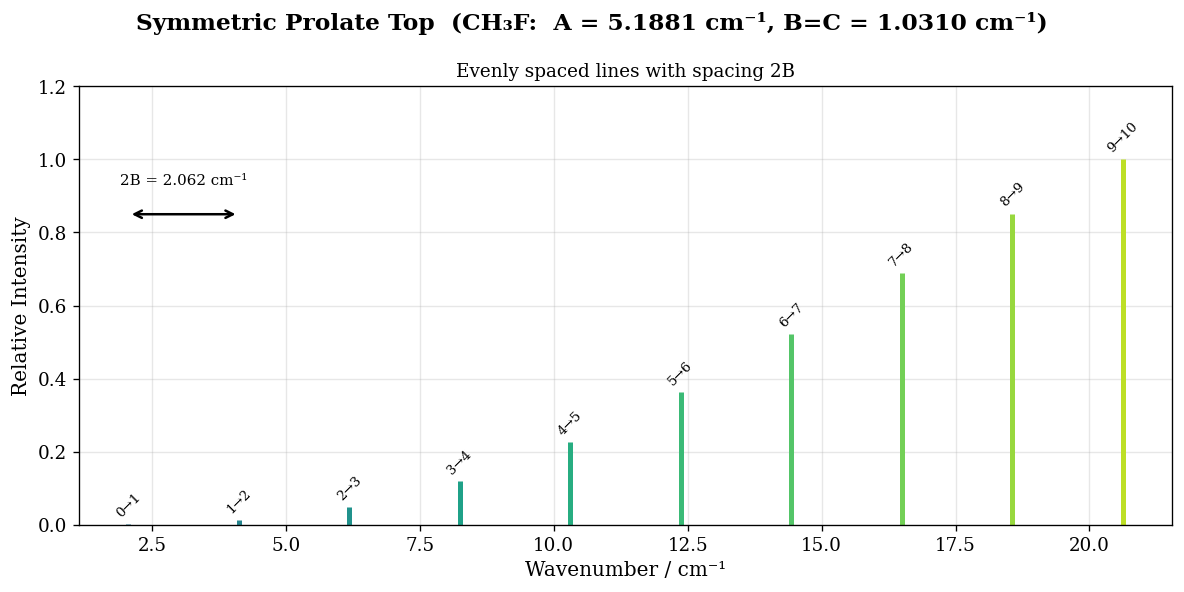

In [132]:
# Plot the prolate symmetric top stick spectrum

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Symmetric Prolate Top  (CH₃F:  A = 5.1881 cm⁻¹, B=C = 1.0310 cm⁻¹)',
             fontsize=14, fontweight='bold')

# Colour-map: each transition gets a slightly different colour so they are
# visually distinguishable, progressing from blue-green to yellow.
colors_pro = plt.cm.viridis(np.linspace(0.4, 0.9, len(transitions_prolate)))

# Draw a vertical line at each transition frequency.
# vlines(x, ymin, ymax) draws a vertical line from 0 to the intensity value.
for i, (nu, I) in enumerate(transitions_prolate):
    ax.vlines(nu, 0, I, color=colors_pro[i], linewidth=3)
    # Label each stick with the J → J+1 assignment, tilted 45° to avoid overlap.
    ax.text(nu, I + 0.02, f'{i}→{i+1}', ha='center', fontsize=8, rotation=45)

ax.set_xlabel('Wavenumber / cm⁻¹', fontsize=12)
ax.set_ylabel('Relative Intensity', fontsize=12)
ax.set_title('Evenly spaced lines with spacing 2B', fontsize=11)
ax.set_ylim(0, 1.2)
ax.axhline(0, color='k', linewidth=0.5)   # baseline

# Annotate the 2B spacing between the first two lines
# A double-headed arrow highlights that consecutive lines are separated by 2B.
nu0, nu1 = transitions_prolate[0][0], transitions_prolate[1][0]
ax.annotate('', xy=(nu1, 0.85), xytext=(nu0, 0.85),
             arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text((nu0 + nu1) / 2, 0.93, f'2B = {nu1 - nu0:.3f} cm⁻¹', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('prolate_top.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Part 2: Symmetric Oblate Top

For an **oblate symmetric top** ($I_A = I_B < I_C$, i.e., $A = B > C$), the energy levels are:

$$E(J, K) = hBJ(J+1) + h(C - B)K^2$$

Since $C < B$, the term $(C - B) < 0$, so **higher K levels have lower energy** — opposite to the prolate case.

**Transition frequencies** ($\Delta J = +1$, $\Delta K = 0$):
$$\tilde{\nu}(J \to J+1) = 2B(J+1)$$

The spectrum is again evenly spaced in $2B$, but the level ordering within each J is inverted.

In [133]:
# Part 3 — Oblate Symmetric Top: NH₃

# Energy formula: E(J,K) = B·J(J+1) + (C−B)·K²
# (C−B) is negative for an oblate top, so levels with larger |K| sit LOWER in energy
# the opposite ordering to a prolate top.
# Despite this, the transition frequencies are the same: ν̃ = 2B(J+1),
# because the K-dependent term again cancels between upper and lower states.

# Rotational constants for NH₃ (cm⁻¹) - calculated above
B_oblate = 9.9745   # A = B for oblate
C_oblate = 6.3423


def oblate_energy(J, K, B, C):
    """
    Return the rotational energy E(J,K) of an oblate symmetric top in cm⁻¹.

    Formula: E(J,K) = B·J(J+1) + (C−B)·K²
    """
    return B * J * (J + 1) + (C - B) * K**2


def oblate_transition_freq(J, B):
    """
    Return the transition frequency (cm⁻¹) for J → J+1.

    Identical in form to the prolate case: ν̃ = 2B(J+1).
    The (C−B)K² term cancels between upper and lower states.
    """
    return 2 * B * (J + 1)


# Energy levels
# Same loop structure as the prolate version.
levels_oblate = []
for J in range(J_max + 1):
    for K in range(0, J + 1):   # K = 0, 1, ..., J  (using |K|)
        E = oblate_energy(J, K, B_oblate, C_oblate)
        levels_oblate.append((J, K, E))

# Transition intensities
# Same Boltzmann + line-strength logic as the prolate calculation.
# Degeneracy_prolate() is reused as the degeneracy formula is identical
# for oblate and prolate symmetric tops.
transitions_oblate = []
for J in range(J_max_spec):
    nu = oblate_transition_freq(J, B_oblate)
    intensity = 0
    for K in range(0, J + 1):
        E_lower = oblate_energy(J, K, B_oblate, C_oblate)
        g        = degeneracy_prolate(J, K)   # same g(J,K) formula
        boltzmann = g * np.exp(-E_lower / (kB_hc * T))
        S         = (J + 1)
        intensity += boltzmann * S
    transitions_oblate.append((nu, intensity))

# Normalise
max_int = max(t[1] for t in transitions_oblate)
transitions_oblate = [(nu, I / max_int) for nu, I in transitions_oblate]

print(f"Oblate top: B = {B_oblate} cm⁻¹, C = {C_oblate} cm⁻¹")
print(f"\nEnergy levels (J, K, E/cm⁻¹):")
for J, K, E in levels_oblate[:15]:
    print(f"  J={J}, K={K:+d}  →  E = {E:.4f} cm⁻¹")


Oblate top: B = 9.9745 cm⁻¹, C = 6.3423 cm⁻¹

Energy levels (J, K, E/cm⁻¹):
  J=0, K=+0  →  E = 0.0000 cm⁻¹
  J=1, K=+0  →  E = 19.9490 cm⁻¹
  J=1, K=+1  →  E = 16.3168 cm⁻¹
  J=2, K=+0  →  E = 59.8470 cm⁻¹
  J=2, K=+1  →  E = 56.2148 cm⁻¹
  J=2, K=+2  →  E = 45.3182 cm⁻¹
  J=3, K=+0  →  E = 119.6940 cm⁻¹
  J=3, K=+1  →  E = 116.0618 cm⁻¹
  J=3, K=+2  →  E = 105.1652 cm⁻¹
  J=3, K=+3  →  E = 87.0042 cm⁻¹
  J=4, K=+0  →  E = 199.4900 cm⁻¹
  J=4, K=+1  →  E = 195.8578 cm⁻¹
  J=4, K=+2  →  E = 184.9612 cm⁻¹
  J=4, K=+3  →  E = 166.8002 cm⁻¹
  J=4, K=+4  →  E = 141.3748 cm⁻¹


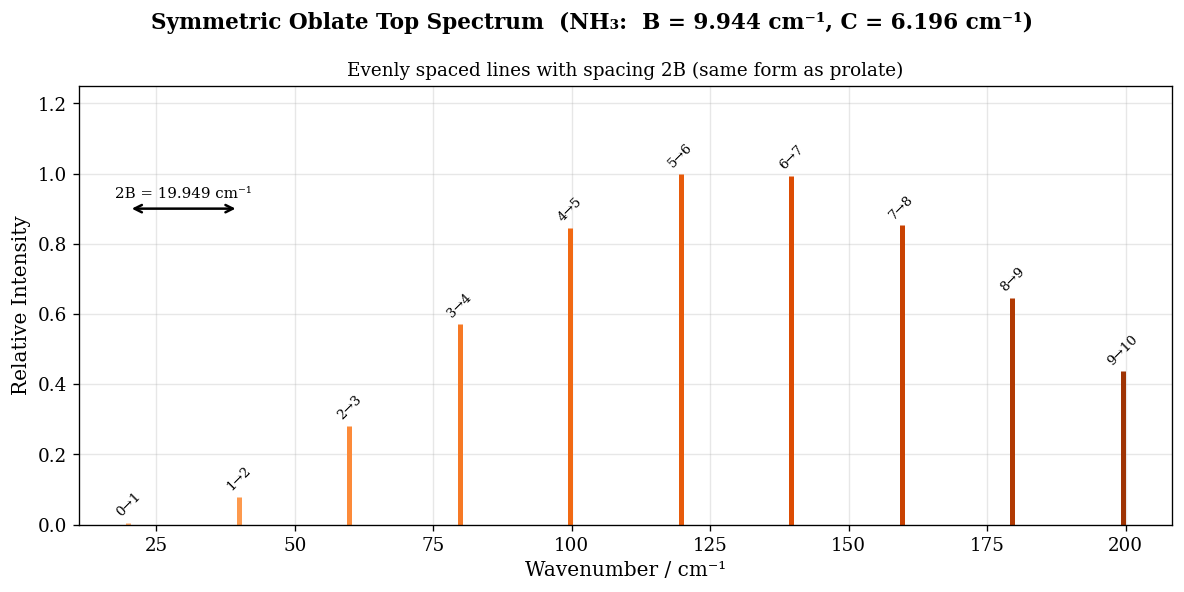

Figure saved as oblate_spectrum.png


In [134]:
# Plot the oblate symmetric top stick spectrum

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Symmetric Oblate Top Spectrum  (NH₃:  B = 9.9745 cm⁻¹, C = 6.3423 cm⁻¹)',
             fontsize=13, fontweight='bold')

# Orange colour-map to visually distinguish this spectrum from the prolate one
colors_obl = plt.cm.Oranges(np.linspace(0.4, 0.9, len(transitions_oblate)))

for i, (nu, I) in enumerate(transitions_oblate):
    ax.vlines(nu, 0, I, color=colors_obl[i], linewidth=3)
    ax.text(nu, I + 0.02, f'{i}→{i+1}', ha='center', fontsize=8, rotation=45)

ax.set_xlabel('Wavenumber / cm⁻¹', fontsize=12)
ax.set_ylabel('Relative Intensity', fontsize=12)
ax.set_title('Evenly spaced lines with spacing 2B (same form as prolate)', fontsize=11)
ax.set_ylim(0, 1.25)
ax.axhline(0, color='k', linewidth=0.5)

# Annotate spacing — confirm lines are separated by 2B as expected
nu0, nu1 = transitions_oblate[0][0], transitions_oblate[1][0]
ax.annotate('', xy=(nu1, 0.9), xytext=(nu0, 0.9),
             arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text((nu0 + nu1) / 2, 0.93, f'2B = {nu1 - nu0:.3f} cm⁻¹', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('oblate_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved as oblate_spectrum.png")
